### Impot Libraries

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import sklearn
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

### Load Dataset 

In [157]:
data1 = datasets.fetch_california_housing()

### Description of the Dataset 

In [158]:
print(data1.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### Coverting the data into Dataframe 
### data1.data contains the all features values of the dataset and data1.feature_names contain the column name of the feature 
### data1.target contains the Target values of the dataset 

In [159]:
data2=pd.DataFrame(data=data1.data, columns=data1.feature_names)
data2["Target"]=data1.target

### Whole Dataset

In [160]:
data2

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### Shape of the Dataset

In [161]:
data2.shape

(20640, 9)

### Info of the Dataset 

In [162]:
data2.info

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       

### Checking the null values of the Dataset 

In [163]:
data2.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

### head() - This prints the first five rows and columns of the Dataset

In [164]:
data2.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### tail() - This prints the last five rows and columns of the Dataset 

In [165]:
data2.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


### y contains Targets of the Dataset 

In [166]:
y = data2["Target"]

### Shape of y 

In [167]:
y.shape

(20640,)

### Printing value of y 

In [168]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Target, Length: 20640, dtype: float64

### In this first we drop the all targets from the dataset and then x contains all the features of the dataset 

In [169]:
x = data2.drop('Target',axis=1)

### Shape of x

In [170]:
x.shape

(20640, 8)

### Printing values of x 

In [171]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### Now, we apply feature scaling using StandardScaler to normalize the input features.

In [172]:
scaler = StandardScaler()
x_scaled = scaler.fit(x)

### The dataset is split into training (80%) and testing (20%) sets. The training set is used to train the model, while the testing set is used to evaluate its performance with Predicted data of the Model.

In [173]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Linear Regression

### Creating the model 

In [175]:
model_lr = LinearRegression()

### Training the model with x_train and y_train 

In [176]:
model_lr.fit(x_train, y_train)

LinearRegression()

### y_pred_lr contains the values which are predicated by model after training it with x_test

In [177]:
y_pred_lr = model_lr.predict(x_test)
print(y_pred_lr)

[2.28110738 2.79009128 1.90332794 ... 0.8418697  2.7984953  2.21779325]


### y_test contains the actual values of the dataset

In [178]:
y_test

14740    1.369
10101    2.413
20566    2.007
2670     0.725
15709    4.600
         ...  
6655     1.695
3505     2.046
1919     1.286
1450     2.595
4148     1.676
Name: Target, Length: 4128, dtype: float64

### EVALUATION MERTICS OF LINEAR REGRESSION 

In [179]:
print("EVALUATION METRICS OF LINEAR REGRESSION : ")
print("Mean Absolute Error : ",mean_absolute_error(y_test, y_pred_lr))
print("Mean Square Error : ",mean_squared_error(y_test, y_pred_lr))
print("r2 Score : ",r2_score(y_test, y_pred_lr))

EVALUATION METRICS OF LINEAR REGRESSION : 
Mean Absolute Error :  0.5351261336554517
Mean Square Error :  0.5289841670367208
r2 Score :  0.5943232652466204


# Decision Tree

### Creating the model 

In [181]:
model_dt = DecisionTreeRegressor()

### Training the model with x_train and y_train 

In [183]:
model_dt.fit(x_train, y_train)

DecisionTreeRegressor()

### y_pred_dt contains the values which are predicated by the model after training it with x_test

In [187]:
y_pred_dt = model_dt.predict(x_test)
print(y_pred_dt)

[1.238 2.518 1.444 ... 1.515 2.869 1.739]


### y_test contains the actual values of the dataset

In [189]:
y_test

14740    1.369
10101    2.413
20566    2.007
2670     0.725
15709    4.600
         ...  
6655     1.695
3505     2.046
1919     1.286
1450     2.595
4148     1.676
Name: Target, Length: 4128, dtype: float64

### EVALUATION METRICS OF DECISION TREE

In [191]:
print("EVALUATION METRICS OF DECISION TREE : ")
print("Mean Absolute Error : ",mean_absolute_error(y_test, y_pred_dt))
print("Mean Square Error : ",mean_squared_error(y_test, y_pred_dt))
print("r2 Score : ",r2_score(y_test, y_pred_dt))

EVALUATION METRICS OF DECISION TREE : 
Mean Absolute Error :  0.47023053052325586
Mean Square Error :  0.536864640197747
r2 Score :  0.5882797485981252


# Random Forest

### Creating a model 

In [194]:
model_rf = RandomForestRegressor()

### Training the model with x_train and y_train

In [196]:
model_rf.fit(x_train, y_train)

RandomForestRegressor()

### y_pred_rf contains the predicated values of the model which has been gotten after training the model with x_test

In [198]:
y_pred_rf = model_rf.predict(x_test)
print(y_pred_rf)

[1.35978 2.41648 1.43081 ... 1.52433 2.74039 1.89445]


### y_test contains the actual values of the dataset

In [200]:
y_test

14740    1.369
10101    2.413
20566    2.007
2670     0.725
15709    4.600
         ...  
6655     1.695
3505     2.046
1919     1.286
1450     2.595
4148     1.676
Name: Target, Length: 4128, dtype: float64

### EVALUATION METRICS OF RANDOM FOREST 

In [206]:
print("EVALUATION METRICS OF RANDOM FOREST : ")
print("Mean Absolute Error : ", mean_absolute_error(y_test, y_pred_rf))
print("Mean Square Error : ", mean_squared_error(y_test, y_pred_rf))
print("r2 Score : ",r2_score(y_test, y_pred_rf))

EVALUATION METRICS OF RANDOM FOREST : 
Mean Absolute Error :  0.3341338287306203
Mean Square Error :  0.2601481930110182
r2 Score :  0.8004929522108442


# Conclusion

In this, different machine learning algorithms were applied to predict housing prices using the California Housing dataset. The dataset contained various geographical, population, and economic features such as median income, house age, average rooms, population, latitude, and longitude.

Three regression models were trained and evaluated: Linear Regression, Decision Tree Regression, and Random Forest Regression. Their performance was compared using evaluation metrics including Mean Absolute Error (MAE), Mean Square Error (MSE), and R² Score.

Among all the models, Random Forest Regression achieved the best performance with the lowest error values and the highest R² Score of 0.80. This indicates that Random Forest was able to capture complex and non-linear relationships within the housing data more effectively than Linear Regression and Decision Tree Regression.

The project demonstrates how machine learning can be used to analyze real-world housing data and generate accurate price predictions. It also highlights the importance of model comparison and evaluation in selecting the most suitable algorithm for predictive tasks.


### Actual vs Predicted Prices of Random Forest 

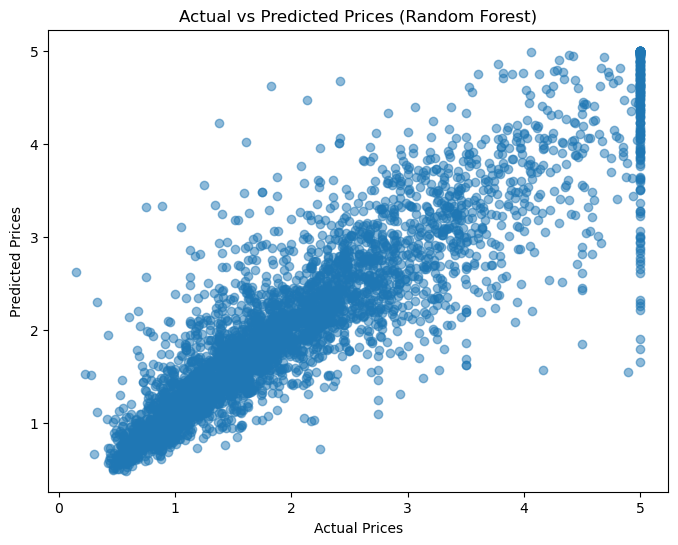

In [241]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()

### Correlation Heatmap of Dataset 

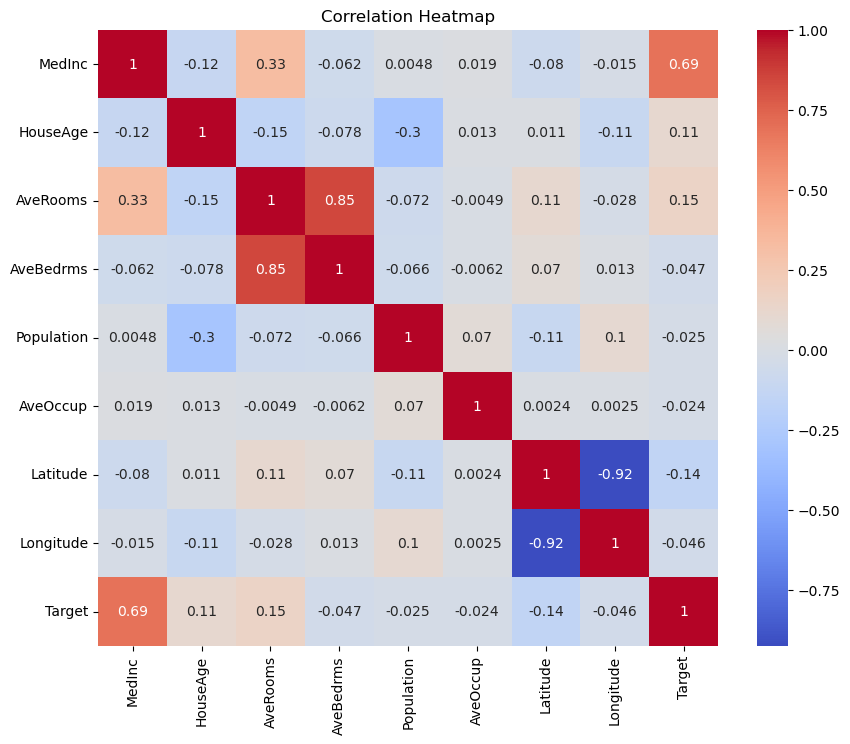

In [247]:
plt.figure(figsize=(10,8))
sb.heatmap(data2.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Feature Importance - Random Forest

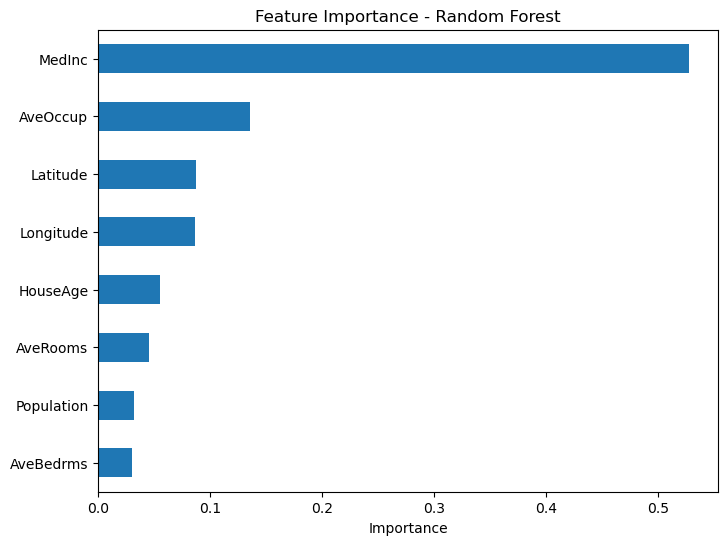

' MedInc - median income in block group '

In [261]:
importance = model_rf.feature_importances_
feature_importance = pd.Series(importance,index=x.columns)
feature_importance.sort_values().plot(kind='barh',figsize=(8,6))

plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.show()
''' MedInc - median income in block group '''

### Overall, Random Forest proved to be the most effective model for accurately predicting California housing prices.